# Partitioning cells

## Import modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from upxo.pxtal.vortess2d import gtess2d

## Set target properties

In [2]:
repr_prop={'area': {'mean': {'val': 50, 'dev': 7.5, },
                            'consider_boundary_grains': True }}

In [3]:
repr_prop

{'area': {'mean': {'val': 50, 'dev': 7.5}, 'consider_boundary_grains': True}}

## Generate base grain structures

In [ ]:
gset = gtess2d.from_seed_points(sp_input='gen', xbound=[0, 25],
         ybound = [0, 25], sp_distr='random', gr_tech='pds',
         smp_tech='bridson1', lean='veryhigh', char_length=[5.],
         ntp=10, ntrials=100, n_instances=2, repr_prop=repr_prop,
         k_char_length_inc=0.05, k_char_length_dec=0.05,)

Generating pxtal. Iteration 1


## Specify grain zstructure instance

In [ ]:
instance_ID_source = 1

## Visualize the grain structure

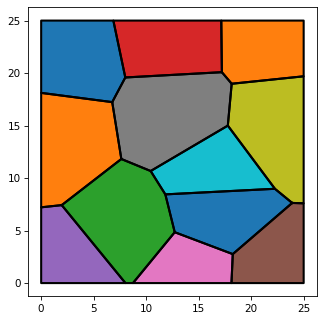

In [ ]:
gset.plot(instance_ID_source)

In [ ]:
pxtal = gset.pxtals[instance_ID_source]

## Select seed cells i.e. seed grains which will be partitioned

In [ ]:
cids_sd = np.random.choice(range(len(gset.pxtals[1].geoms)), 3, replace=False)

## Partition the above cells

In [ ]:
sc = gset.partition_cells(gslevel='base', instance_ID_source=1,
                          instance_ID_partition=1,
                          cids_sd=cids_sd,
                    partition_type='Sub-cell-0',
                    arg={'cid_offset': -1, 'spn': 10,
                         'id_format': 'from_cid_max',
                         'seed_lattice_type': 'rand_uni',
                         'combine_small_subs': False,
                         '_buffer_factor_': 0.8,
                         '_min_subcell_area_factor_': 0.09,
                         'niter_max': 1000, '_force_select_': True},
                    saa=True, plot_pxtal=True, throw_pxtal=True)

TypeError: Invalid cids value type.

lets gather all the sub-cell IDs. Lets just get all those from whose
        parent cells have atleast 2 subcells.


In [ ]:
cids_sd_level_1 = []
for _sc_ in sc['fmap'].values():
    if len(_sc_) > 1:
        cids_sd_level_1 += _sc_

In [ ]:
sc = gset.partition_cells(gslevel='subgrains', instance_ID_source=1,
                                  instance_ID_partition=2,
                                  cids_sd=cids_sd_level_1,
                            partition_type='Sub-cell-0',
                            arg={'cid_offset': -1, 'spn': 10,
                                 'id_format': 'from_cid_max',
                                 'seed_lattice_type': 'rand_uni',
                                 'combine_small_subs': False,
                                 '_buffer_factor_': 0.8,
                                 '_min_subcell_area_factor_': 0.04,
                                 'niter_max': 1000, '_force_select_': True},
                            saa=True, plot_pxtal=True, throw_pxtal=True)

In [ ]:
cids_sd_level_1 = []
for _sc_ in sc['fmap'].values():
    if len(_sc_) > 1:
        cids_sd_level_1 += _sc_

In [ ]:
sc = gset.partition_cells(gslevel='subgrains', instance_ID_source=2,
                          instance_ID_partition=3,
                          cids_sd=cids_sd_level_1,
                          partition_type='Sub-cell-0',
                          arg={'cid_offset': -1, 'spn': 10,
                               'id_format': 'from_cid_max',
                               'seed_lattice_type': 'rand_uni',
                               'combine_small_subs': False,
                               '_buffer_factor_': 0.8,
                               '_min_subcell_area_factor_': 0.04,
                               'niter_max': 1000, '_force_select_': True},
                          saa=True, plot_pxtal=True, throw_pxtal=True)